(1000, 1)


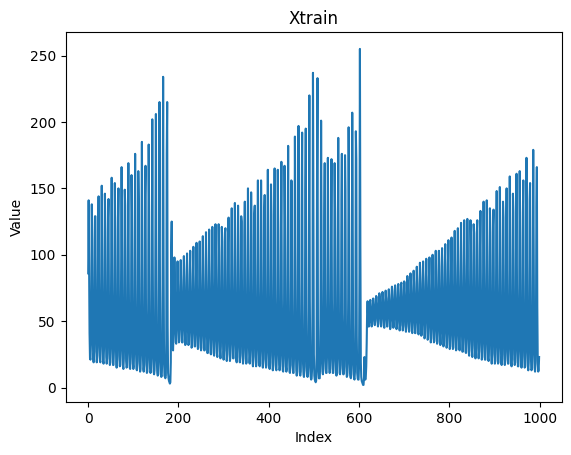

In [ ]:
from scipy.io import loadmat

data = loadmat("Xtrain.mat")   # path to the file
x = data["Xtrain"]             # extract variable

print(x.shape)                 # should be (1000, 1)

x = x.flatten()   # now shape (1000,)

z = x[0:1000]

import matplotlib.pyplot as plt

plt.plot(z)
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Xtrain")
plt.show()

seq_len= 10  →  MAE=23.5287  MSE=1824.1186
seq_len= 20  →  MAE=30.9238  MSE=1982.1304
seq_len= 30  →  MAE=39.4063  MSE=3706.0149
seq_len= 50  →  MAE=38.1202  MSE=3566.0616
seq_len= 80  →  MAE=32.3455  MSE=1828.0741

Best sequence length: 10


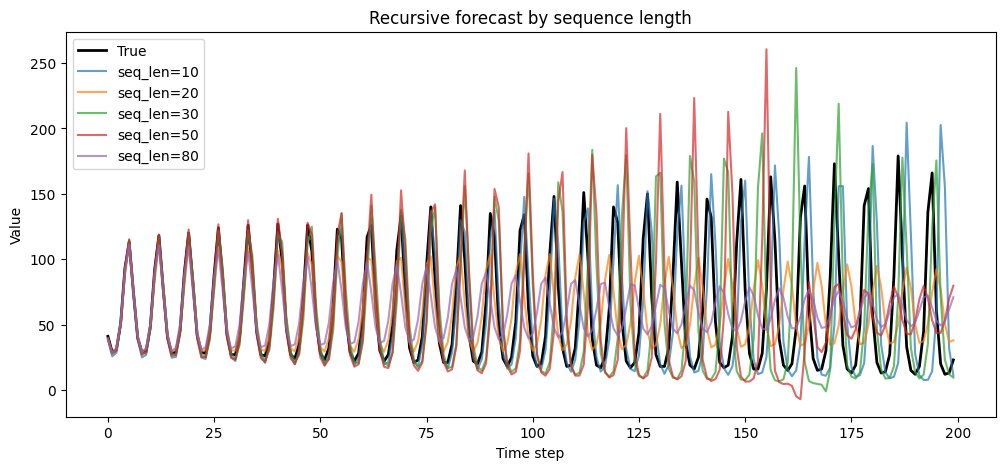

In [ ]:
"""
 Sequence length tuning
Train on first 800 points, recursively forecast last 200,
compare against real values to find the best seq_len for recursive prediction.
"""

import numpy as np
import scipy.io
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt


mean = x.mean()
std = x.std()
x_norm = (x - mean) / std

x_norm_train = x_norm[:800]
x_real_test = x[800:]  # original scale


x_norm_train = x_norm[:800]
x_real_test = x[800:]  # original scale

seq_lengths = [10, 20, 30, 50, 80]
results = {}

for sl in seq_lengths:
    tf.random.set_seed(1)
    np.random.seed(1)

    # Build sequences from first 800 points
    X_tune, y_tune = [], []
    for i in range(len(x_norm_train) - sl):
        X_tune.append(x_norm_train[i:i+sl])
        y_tune.append(x_norm_train[i+sl])
    X_tune = np.array(X_tune)[..., None]
    y_tune = np.array(y_tune)

    # Fresh LSTM
    tune_model = models.Sequential([
        layers.Input(shape=(sl, 1)),
        layers.LSTM(64, return_sequences=True),
        layers.LSTM(32),
        layers.Dense(1)
    ])
    tune_model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss="mse")
    tune_model.fit(X_tune, y_tune, epochs=100, batch_size=32,
                   validation_split=0.2, shuffle=True, verbose=0)

    # Recursive 200-step forecast
    window = x_norm_train[-sl:].copy()
    preds_norm = []
    for _ in range(200):
        pred_val = tune_model.predict(window.reshape(1, sl, 1), verbose=0)[0, 0]
        preds_norm.append(pred_val)
        window = np.append(window[1:], pred_val)

    preds = np.array(preds_norm) * std + mean
    mae = np.mean(np.abs(preds - x_real_test))
    mse = np.mean((preds - x_real_test) ** 2)
    results[sl] = {"mae": mae, "mse": mse, "preds": preds}
    print(f"seq_len={sl:>3d}  →  MAE={mae:.4f}  MSE={mse:.4f}")

# Summary
best_sl = min(results, key=lambda s: results[s]["mse"])
print(f"\nBest sequence length: {best_sl}")

# Comparison plot
plt.figure(figsize=(12, 5))
plt.plot(x_real_test, label="True", color="black", linewidth=2)
for sl in seq_lengths:
    plt.plot(results[sl]["preds"], label=f"seq_len={sl}", alpha=0.7)
plt.legend()
plt.title("Recursive forecast by sequence length")
plt.xlabel("Time step")
plt.ylabel("Value")
plt.show()

dict_keys(['__header__', '__version__', '__globals__', 'Xtrain'])
Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.8768 - val_loss: 0.6333
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5228 - val_loss: 0.1586
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3223 - val_loss: 0.0439
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2470 - val_loss: 0.0173
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2133 - val_loss: 0.0166
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1995 - val_loss: 0.0171
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1902 - val_loss: 0.0158
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1815 - val_loss: 0.0146
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1728 - val_loss: 0.0137
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1642 - val_loss: 0.0130
Epoch 11/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1553 - val_loss: 

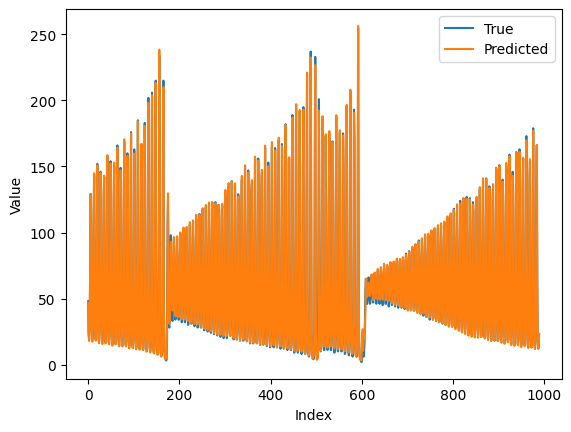

In [ ]:
import numpy as np
import scipy.io
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# reproducibility
np.random.seed(1)
tf.random.set_seed(1)

# 1. Load data
mat = scipy.io.loadmat("Xtrain.mat")
print(mat.keys())

# change key if needed
x = mat["Xtrain"]
x = np.asarray(x).squeeze().astype("float32")

# 2. Normalize
mean = x.mean()
std = x.std()
x_norm = (x - mean) / std

# 3. Make sequences
seq_len = best_sl

X, y = [], []
for i in range(len(x_norm) - seq_len):
    X.append(x_norm[i:i+seq_len])
    y.append(x_norm[i+seq_len])

X = np.array(X)[..., None]   # (samples, seq_len, 1)
y = np.array(y)              # (samples,)

# 4. LSTM model
model = models.Sequential([
    layers.Input(shape=(seq_len, 1)),
    layers.LSTM(64, return_sequences=True),
    layers.LSTM(32),
    layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

# 5. Train
history = model.fit(
    X, y,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    shuffle=True
)

# 6. Predict
pred_norm = model.predict(X).squeeze()
pred = pred_norm * std + mean
true = y * std + mean


#saving things

model.save("lstm_model.keras")

np.savez("scaling_params.npz", mean=mean, std=std, seq_len=seq_len)

# 7. Plot
plt.plot(true, label="True")
plt.plot(pred, label="Predicted")
plt.legend()
plt.xlabel("Index")
plt.ylabel("Value")
plt.show()

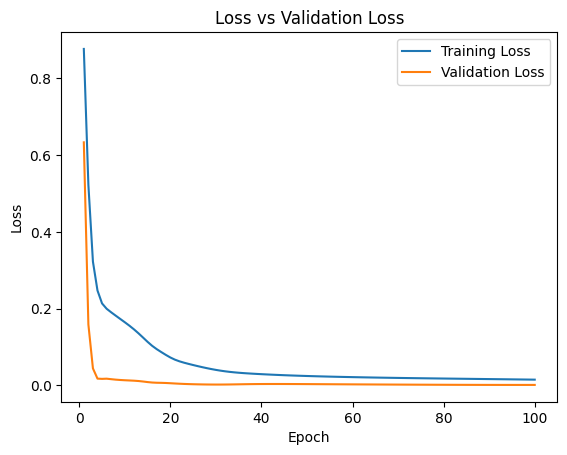

In [ ]:
# Plot training vs validation loss
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(loss) + 1)

plt.figure()
plt.plot(epochs, loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Validation Loss")
plt.legend()
plt.show()

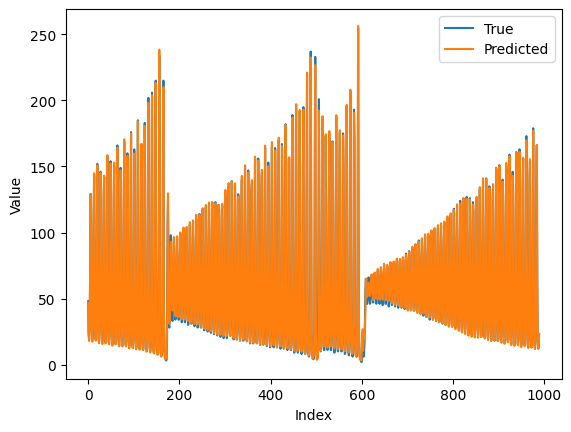

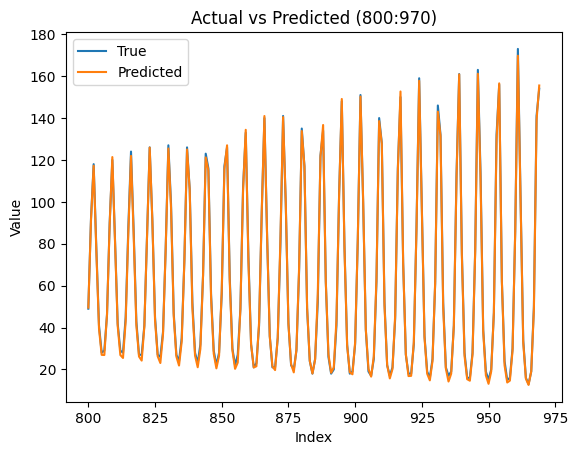

In [ ]:
# 7. Plot
plt.plot(true, label="True")
plt.plot(pred, label="Predicted")
plt.legend()
plt.xlabel("Index")
plt.ylabel("Value")
plt.show()


# plot only a specific interval (e.g., 0:100)

start = 800
end = 970

plt.figure()
plt.plot(range(start, end), true[start:end], label="True")
plt.plot(range(start, end), pred[start:end], label="Predicted")
plt.legend()
plt.xlabel("Index")
plt.ylabel("Value")
plt.title(f"Actual vs Predicted ({start}:{end})")
plt.show()

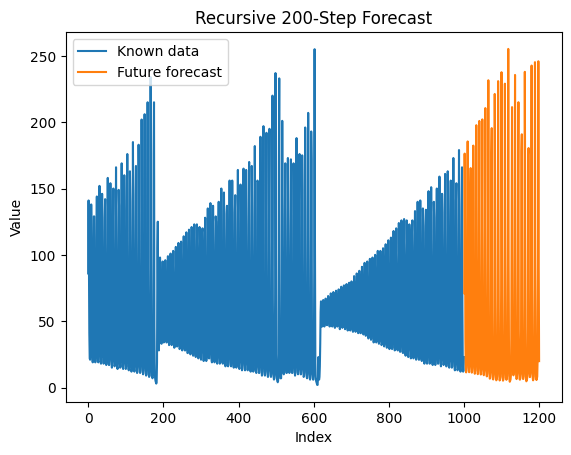

In [ ]:
# Recursive forecast for next 200 points

n_future = 200

# start with the last known 30 normalized values
current_window = x_norm[-seq_len:].copy()

future_preds_norm = []

for _ in range(n_future):
    # shape: (1, seq_len, 1)
    input_seq = current_window.reshape(1, seq_len, 1)

    # predict next normalized value
    next_pred_norm = model.predict(input_seq, verbose=0)[0, 0]

    future_preds_norm.append(next_pred_norm)

    # slide window forward: remove oldest, add prediction
    current_window = np.append(current_window[1:], next_pred_norm)

# convert back to original scale
future_preds = np.array(future_preds_norm) * std + mean

# plot
plt.figure()
plt.plot(range(len(x)), x, label="Known data")
plt.plot(
    range(len(x), len(x) + n_future),
    future_preds,
    label="Future forecast"
)
plt.legend()
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Recursive 200-Step Forecast")
plt.show()

# Test Data

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.9103 - val_loss: 0.6881
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5498 - val_loss: 0.1456
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3023 - val_loss: 0.0300
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2368 - val_loss: 0.0172
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.2151 - val_loss: 0.0210
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2034 - val_loss: 0.0214
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1948 - val_loss: 0.0197
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1876 - val_loss: 0.0179
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1808 - val_loss: 0.0163
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1739 - val_loss: 0.0149
Epoch 11/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1669 - val_loss: 0.0137
Epoch 12/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - 

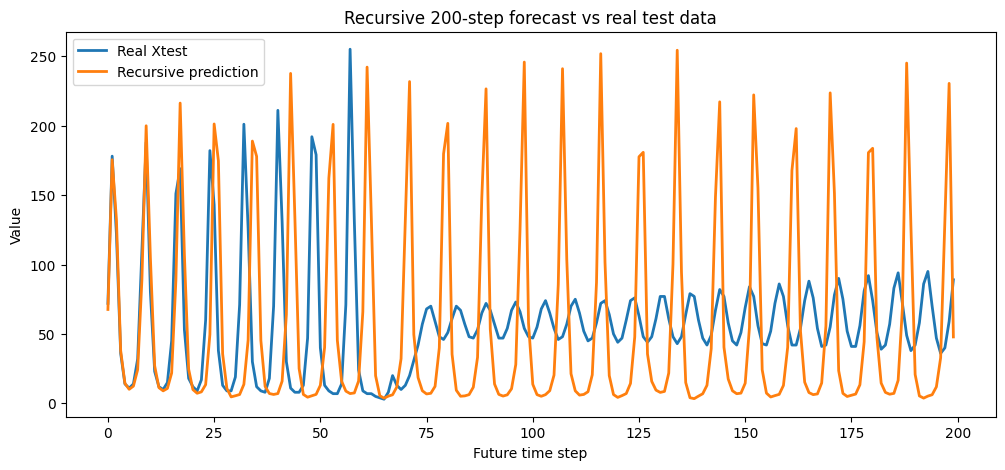

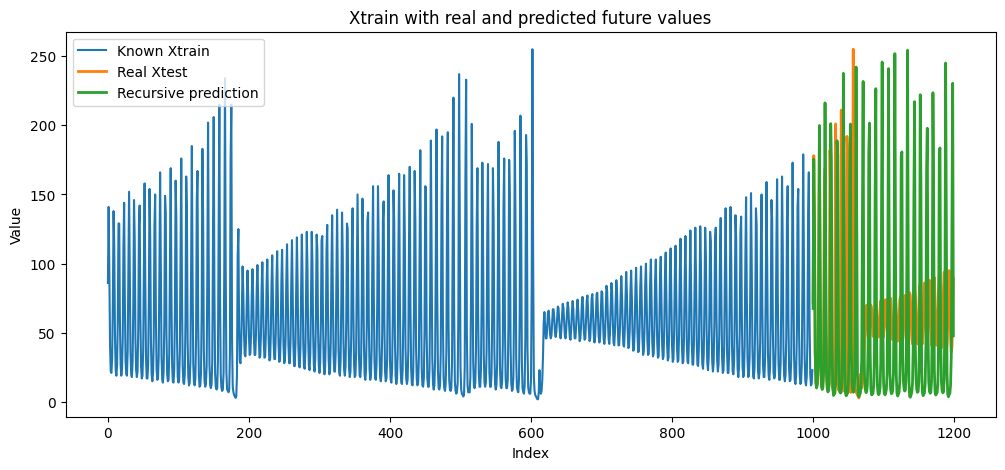

In [ ]:
import numpy as np
import scipy.io
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(1)
tf.random.set_seed(1)

train_mat = scipy.io.loadmat("Xtrain.mat")
x_train = np.asarray(train_mat["Xtrain"]).squeeze().astype("float32")

test_mat = scipy.io.loadmat("Xtest.mat")
x_test = np.asarray(test_mat["Xtest"]).squeeze().astype("float32")
x_test = x_test[:200]

mean = x_train.mean()
std = x_train.std()
x_train_norm = (x_train - mean) / std

seq_len = 10

X, y = [], []
for i in range(len(x_train_norm) - seq_len):
    X.append(x_train_norm[i:i+seq_len])
    y.append(x_train_norm[i+seq_len])

X = np.array(X)[..., None]
y = np.array(y)

model = models.Sequential([
    layers.Input(shape=(seq_len, 1)),
    layers.LSTM(64, return_sequences=True),
    layers.LSTM(32),
    layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

history = model.fit(
    X, y,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    shuffle=True,
    verbose=1
)

# Recursive 200-step prediction
n_future = 200
current_window = x_train_norm[-seq_len:].copy()

preds_norm = []

for _ in range(n_future):
    input_seq = current_window.reshape(1, seq_len, 1)
    next_pred_norm = model.predict(input_seq, verbose=0)[0, 0]
    preds_norm.append(next_pred_norm)
    current_window = np.append(current_window[1:], next_pred_norm)

# Rescale predictions
preds = np.array(preds_norm) * std + mean

# Evaluation on real Xtest
mae = mean_absolute_error(x_test, preds)
mse = mean_squared_error(x_test, preds)

print(f"Final test MAE: {mae:.4f}")
print(f"Final test MSE: {mse:.4f}")

# Plot test prediction vs real test data
plt.figure(figsize=(12, 5))
plt.plot(x_test, label="Real Xtest", linewidth=2)
plt.plot(preds, label="Recursive prediction", linewidth=2)
plt.xlabel("Future time step")
plt.ylabel("Value")
plt.title("Recursive 200-step forecast vs real test data")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(range(len(x_train)), x_train, label="Known Xtrain")
plt.plot(
    range(len(x_train), len(x_train) + len(x_test)),
    x_test,
    label="Real Xtest",
    linewidth=2
)
plt.plot(
    range(len(x_train), len(x_train) + len(preds)),
    preds,
    label="Recursive prediction",
    linewidth=2
)
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Xtrain with real and predicted future values")
plt.legend()
plt.show()